📂 Loading FinBERT labeled data...

📊 Distribusi sentimen FinBERT:
  Sentiment  Count   Source
0   neutral   4092    Title
1  negative   2935    Title
2  positive   1130    Title
0   neutral   5533  Content
1  positive   1451  Content
2  negative   1173  Content


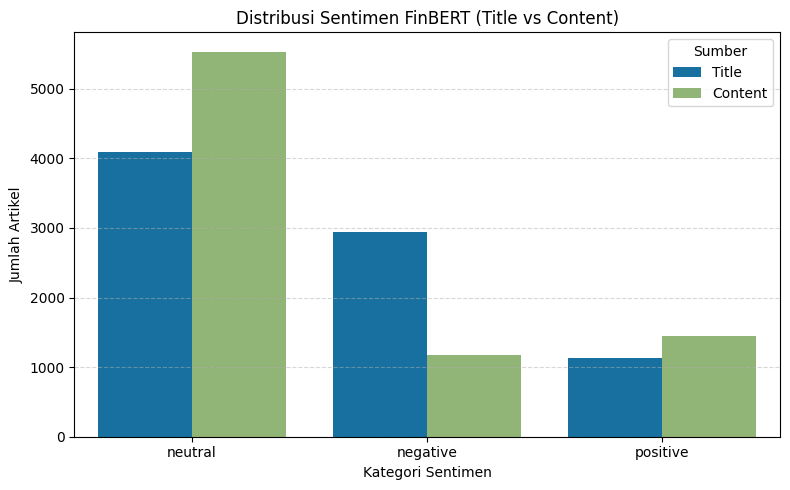

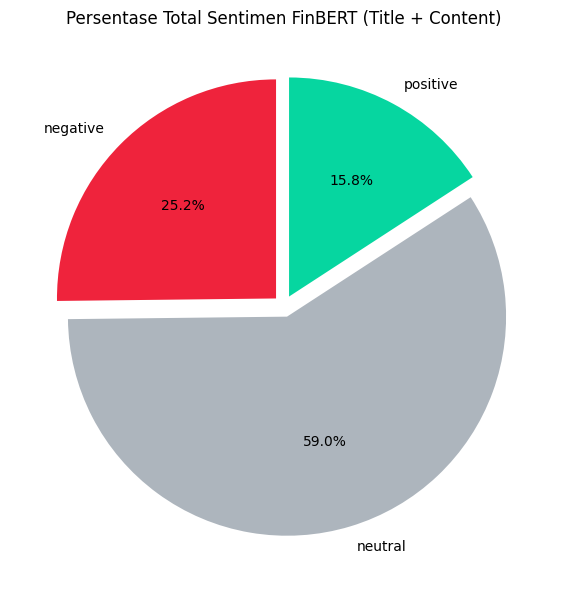

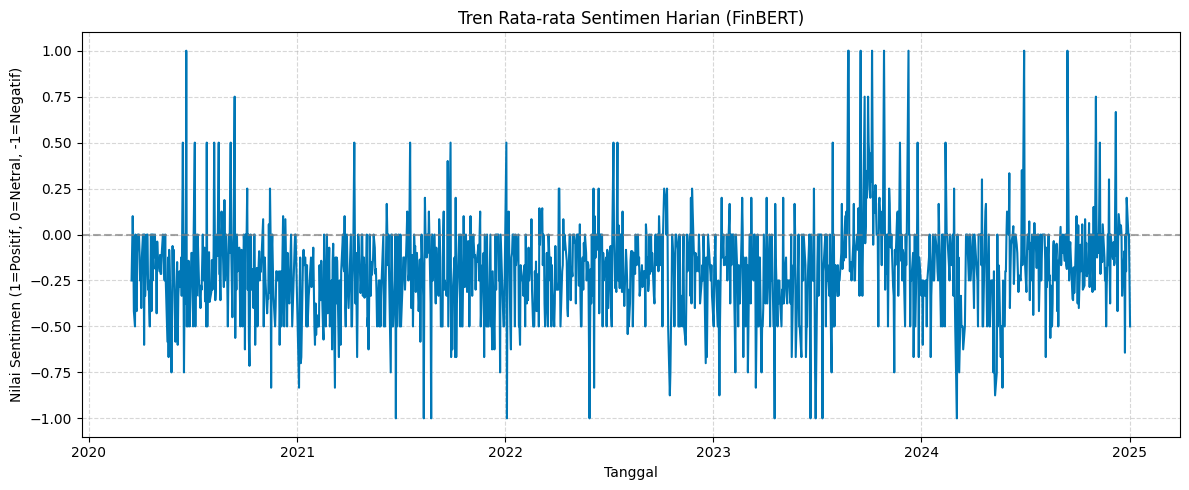


✅ Visualisasi sentimen FinBERT selesai!


In [1]:
#!/usr/bin/env python3
"""
visualize_finbert_sentiment.py
Visualisasi distribusi dan tren sentimen hasil FinBERT
(title dan content) dari file labeled_articles_final_FinBERT.xlsx.
"""

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# ==========================================================
# CONFIG
# ==========================================================
finbert_file = r"D:\Skripsi\Data\Kode Ekstrak\output\labeled_articles_final_FinBERT.xlsx"

# ==========================================================
# LOAD DATA
# ==========================================================
print("📂 Loading FinBERT labeled data...")
df = pd.read_excel(finbert_file)

# Pastikan kolom lowercase
df.columns = df.columns.str.lower().str.strip()

# Pastikan kolom tanggal ada
if "date" not in df.columns:
    raise ValueError("❌ Kolom 'date' tidak ditemukan di file FinBERT!")

df["date"] = pd.to_datetime(df["date"], errors="coerce")

# ==========================================================
# VALIDASI KETERSEDIAAN KOLOM
# ==========================================================
required_cols = ["t_predict", "c_predict"]
missing_cols = [col for col in required_cols if col not in df.columns]
if missing_cols:
    raise ValueError(f"❌ Kolom berikut tidak ditemukan: {missing_cols}")

# ==========================================================
# HITUNG DISTRIBUSI SENTIMEN
# ==========================================================
title_counts = df["t_predict"].value_counts().reset_index()
title_counts.columns = ["Sentiment", "Count"]
title_counts["Source"] = "Title"

content_counts = df["c_predict"].value_counts().reset_index()
content_counts.columns = ["Sentiment", "Count"]
content_counts["Source"] = "Content"

sent_counts = pd.concat([title_counts, content_counts])

print("\n📊 Distribusi sentimen FinBERT:")
print(sent_counts)

# ==========================================================
# VISUALISASI 1: BAR CHART PER SUMBER
# ==========================================================
plt.figure(figsize=(8, 5))
sns.barplot(
    data=sent_counts,
    x="Sentiment",
    y="Count",
    hue="Source",
    palette={"Title": "#0077b6", "Content": "#90be6d"}
)
plt.title("Distribusi Sentimen FinBERT (Title vs Content)")
plt.xlabel("Kategori Sentimen")
plt.ylabel("Jumlah Artikel")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.legend(title="Sumber", loc="upper right")
plt.tight_layout()
plt.show()

# ==========================================================
# VISUALISASI 2: PIE CHART (TOTAL GABUNGAN)
# ==========================================================
combined_counts = sent_counts.groupby("Sentiment")["Count"].sum().reset_index()

plt.figure(figsize=(6, 6))
plt.pie(
    combined_counts["Count"],
    labels=combined_counts["Sentiment"],
    autopct="%1.1f%%",
    startangle=90,
    colors=["#ef233c", "#adb5bd", "#06d6a0"],
    explode=[0.05, 0.05, 0.05],
)
plt.title("Persentase Total Sentimen FinBERT (Title + Content)")
plt.tight_layout()
plt.show()

# ==========================================================
# VISUALISASI 3: TREND SENTIMEN HARIAN
# ==========================================================
# Ubah label ke nilai numerik agar bisa diplot (pos=1, net=0, neg=-1)
label_map = {"positive": 1, "neutral": 0, "negative": -1}

df["title_sent_value"] = df["t_predict"].map(label_map)
df["content_sent_value"] = df["c_predict"].map(label_map)
df["mean_sentiment"] = df[["title_sent_value", "content_sent_value"]].mean(axis=1)

# Agregasi harian
daily_sentiment = df.groupby("date")["mean_sentiment"].mean().reset_index()

plt.figure(figsize=(12, 5))
sns.lineplot(data=daily_sentiment, x="date", y="mean_sentiment", color="#0077b6", linewidth=1.5)
plt.axhline(0, color="gray", linestyle="--", alpha=0.7)
plt.title("Tren Rata-rata Sentimen Harian (FinBERT)")
plt.xlabel("Tanggal")
plt.ylabel("Nilai Sentimen (1=Positif, 0=Netral, -1=Negatif)")
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

print("\n✅ Visualisasi sentimen FinBERT selesai!")
